In [1]:
import datetime as dt
import os
import sys

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

# import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import (
    domains,
    get_nn_lon_lat_index,
    haversine,
    hp_mods,
    hp_to_latlon,
    sim_colors,
    sim_labels,
    sims,
)

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/franmorr/.conda/envs/hk26_env/share/proj failed


link to [#Add-monsoon-regions-only](#Add-monsoon-regions-only)

In [3]:

# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'

# sim = 'um_glm_n1280_GAL9_v2_hk26'
# sim = 'um_glm_n2560_CoMA9_hk26'
# sim = 'um_glm_n1280_CoMA9_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=4, time='PT1H').to_dask().pipe(hp_mods)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


NameError: name 'hp_mods' is not defined

In [9]:
[sim for sim in intake.open_catalog(url)["UK"]]

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'arp-gem-1p3km',
 'arp-gem-2p6km',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'ifs_tco3999_rcbmf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_CoMA9_hk26',

In [3]:
sim = "icon_d3hp003"
sim_cat = cat[sim]
# ds = sim_cat(time="PT6H").to_dask()


In [6]:
zoom = 5
ds = hp_to_latlon(
    sim_cat(zoom=zoom).to_dask().pipe(egh.attach_coords).pr, zoom=zoom
).sel(longitude=30, latitude=-20, method="nearest")

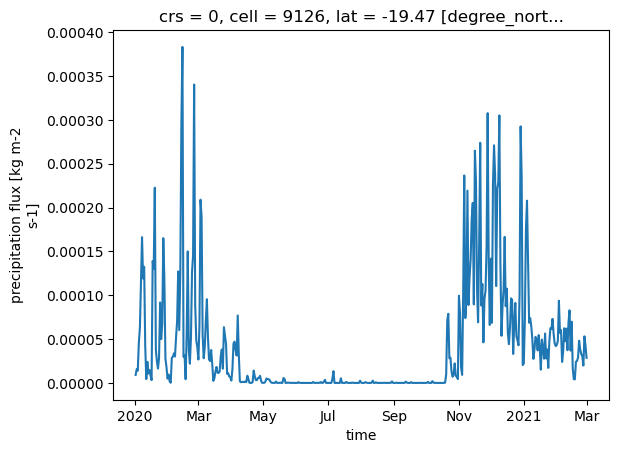

In [7]:
ds.plot()

## Onset Period analysis

Marcia's technique takes the following steps:
1. Butterworth filter precipitation timeseries with a 60-day window Pr_{60}
2. Take time derivative of Pr_{60}
3. Identify periods where Pr_{60} and dPr_{60}/dt are positive for 30 days or more.
4. Apply RefineOns to cut out parts which are just dry at the start or end of the identified onset period. This takes the filtered rainfall and requires that it exceeds its 10th percentile (as standard; can be changed) in order to be included as part of the onset.

The functions to calculate onset period for a single time series can be found in `onset_utils.py`. There is also a function to determine seasonality as in [Kahana et al. (2024)](https://www.frontiersin.org/journals/climate/articles/10.3389/fclim.2024.1419704/full), but ultimately this has not been used in analysis. `OnsetPeriod_toolbox.py` contains useful functions to facilitate onset calculations, including `RefineOns()`. 


In [21]:
for cell_ix in range(len(ds.pr.cell)):
    if cell_ix%10==0:
        print(cell_ix,(ds.sel(cell=cell_ix).lon.values,ds.sel(cell=cell_ix).lat.values))

AttributeError: 'DataArray' object has no attribute 'pr'

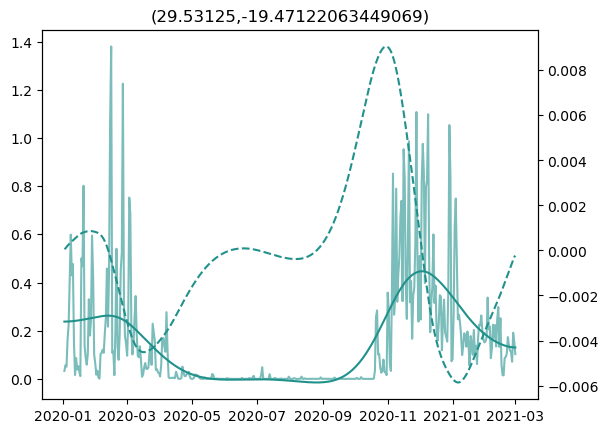

In [17]:
import OnsetPeriod_toolbox as optb
from onset_utils import onset_period_1d

fwin = 60
minlen = 30
# for cell_ix in [0, 1000, 1220, 2250, 3054]:
for cell_ix in [1461]:
    color = plt.cm.viridis(0.5)
    pp = (
        hp_to_latlon(sim_cat(zoom=zoom).to_dask().pipe(egh.attach_coords).pr, zoom=zoom)
        .sel(longitude=30, latitude=-20, method="nearest")
        .resample(time="1D")
        .mean()
        * 3600
    )

    flt = optb.butterworth(pp, fwin)
    grd = np.gradient(flt)
    fds, lds = onset_period_1d(
        pp,
        pp.time.values,
        refine=False,
        # precip_threshold=0.05,
        # intensity_threshold="60%",
    )

    fig, ax = plt.subplots()

    ax.plot(pp.time.values, pp, color=color, alpha=0.6)
    [
        ax.axvspan(
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(fds[ix]) - 1),
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(lds[ix]) - 1),
            alpha=0.1,
            color=color,
        )
        for ix in range(len(fds))
        if 0 <= int(fds[ix]) <= 366 and 0 <= int(lds[ix]) <= 366
    ]
    ax.plot(
        pp.time,
        flt,
        color=color,
    )
    ax.set_title(f"({pp.lon.data},{pp.lat.data})")

    ax2 = ax.twinx()

    ax2.plot(pp.time, grd, "--", color=color)

In [4]:
def constrain_healpix(ds, left, right, bottom, top):
    region_mask = (
        (ds.lon > left) & (ds.lon < right) & (ds.lat > bottom) & (ds.lat < top)
    )
    return ds.where(region_mask)

In [ ]:
chirps = xr.open_dataarray(
    "/home/users/franmorr/firstrains/OnsetPeriod/data/CHIRPS/CHIRPS_precip.day.total_1981-2025.025dg.aw.nc"
)

# chirps.sel(longitude=357.25,latitude=14.5,time=slice("2020-01-21","2021-03-31")).plot()
chirps.sel(longitude=76,latitude=9.5,time=slice("2020-01-21","2021-03-31")).plot()

In [ ]:
import OnsetPeriod_toolbox as optb
from onset_utils import onset_period_1d

fwin = 60
minlen = 30
# for cell_ix in [0, 1000, 1220, 2250, 3054]:
for cell_ix in [0]:
    color = plt.cm.viridis(0.6)
    pp = chirps.sel(longitude=76,latitude=9.5,time=slice("2020-01-21","2021-03-31")) / 24

    flt = optb.butterworth(pp, fwin)
    grd = np.gradient(flt)
    fds, lds = onset_period_1d(
        pp,
        pp.time,
        refine=True,
        # precip_threshold=0.05,
        # intensity_threshold="60%",
    )

    fig, ax = plt.subplots()

    ax.plot(pp.time, pp, color=color, alpha=0.6)
    [
        ax.axvspan(
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(fds[ix]) - 1),
            dt.datetime(2020, 1, 1) + dt.timedelta(days=int(lds[ix]) - 1),
            alpha=0.1,
            color=color,
        )
        for ix in range(len(fds))
        if int(fds[ix] == fds[ix])
    ]
    ax.plot(
        pp.time,
        flt,
        color=color,
    )
    ax.set_title(f"CHIRPS @ ({pp.longitude.data},{pp.latitude.data})")

    ax2 = ax.twinx()

    ax2.plot(pp.time, grd, "--", color=color)

# Plot maps of onset data

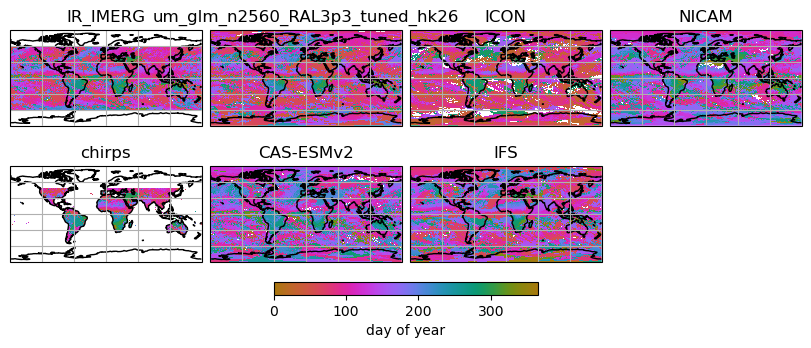

In [14]:
def plot_first_day(ax, sim, extent=None, zoom=7, period_ix=0, thresholds="nofilter"):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()

    if sim.lower() == "chirps":
        da = (
            xr.open_dataset(f"onset_dates/{thresholds}/chirps_2020_dwtps.nc")
            .sel(period=period_ix)
            .first_day_of_period
        )
    else:
        if extent[3]<-5 and "icon" in sim:
            period_ix=1
        else:
            period_ix=0
        
        da = (
            xr.open_dataset(f"onset_dates/{thresholds}/{sim}_zoom_{zoom}_dwtps.nc")
            .sel(period=period_ix)
            .first_day_of_period
        )
        
    m = da.plot(cmap=cmo.cm.phase, vmin=0, vmax=365, ax=ax, add_colorbar=False)
    ax.set_title(sim)
    if "hk26" in sim:
        if "RAL3" in sim:
            ax.set_title("UM_RAL3")
        if "_n2560_CoMA9_" in sim:
            ax.set_title("CoMA9 5km")
        if "_n1280_CoMA9_" in sim:
            ax.set_title("CoMA9 10km")
        if "GAL9" in sim:
            ax.set_title("GAL9")
    ax.set_title(sim)
    if "casesm" in sim:
        ax.set_title("CAS-ESMv2")
    if "icon" in sim:
        ax.set_title("ICON")
    if "ifs" in sim:
        ax.set_title("IFS")
    if "nicam" in sim:
        ax.set_title("NICAM")
    ax.coastlines()
    ax.gridlines()
    return ax, m


# # South America
# left = -80
# right = -30
# bottom = -40
# top = 10
# figsize = (6, 6)


# # South Africa
# left=10
# right=50
# bottom=-40
# top=0
# figsize=(6,6)


# West Africa
# left = -30
# right = 20
# bottom = 0
# top = 30
# # figsize=None


# India
# left = 60
# right = 100
# bottom = 0
# top = 40
# figsize=(6,6)


# # East Asia
# left=100
# right=140
# bottom=10
# top=50
# figsize=(6,6)

# # Globe
left = -180
right = 180
bottom = -90
top = 90
figsize = (8, 3.5)

thresholds = ""

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    4,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_first_day(
    axes[0, 0], "IR_IMERG", [left, right, bottom, top], thresholds=thresholds, zoom=9
)

ax, m = plot_first_day(
    axes[1, 0], "chirps", [left, right, bottom, top], thresholds=thresholds
)

ax, m = plot_first_day(
    axes[0, 1],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)

ax, m = plot_first_day(
    axes[0, 2],
    "icon_d3hp003",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[1, 1],
    "casesm2_10km_nocumulus",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[1, 2],
    "ifs_tco3999-ng5_rcbmf_cf",
    [left, right, bottom, top],
    thresholds=thresholds,
)

ax, m = plot_first_day(
    axes[0, 3],
    "nicam_gl11",
    [left, right, bottom, top],
    thresholds=thresholds,
)
# ax, m = plot_first_day(
#     axes[1, 2],
#     "scream-dkrz",
#     [left, right, bottom, top],
#     thresholds=thresholds,
# )

fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="day of year",
)
# fig.suptitle(f"{thresholds} | zoom {zoom}")
axes[1,3].set_frame_on(False)


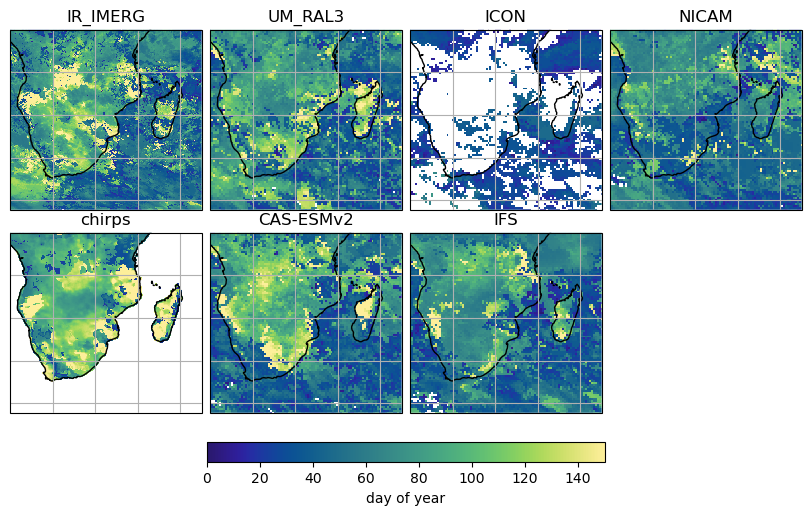

In [9]:

def plot_length(ax, sim, extent=None, zoom=7, period_ix=0, thresholds="nofilter"):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()

    if sim.lower() == "chirps":
        ds = (
            xr.open_dataset(f"onset_dates/{thresholds}/chirps_2020_dwtps.nc")
            .sel(period=period_ix)
        )
    else:
        if extent[2]<-5 and "icon" in sim:
            period_ix=1
            print("weird icon")
        else:
            period_ix=0
        ds = (
            xr.open_dataset(f"onset_dates/{thresholds}/{sim}_zoom_{zoom}_dwtps.nc")
            .sel(period=period_ix)
        )
    da = ds.last_day_of_period - ds.first_day_of_period
    m = da.plot(cmap=cmo.cm.haline, vmin=0, vmax=150, ax=ax, add_colorbar=False)
    ax.set_title(sim)
    if "hk26" in sim:
        if "RAL3" in sim:
            ax.set_title("UM_RAL3")
    ax.set_title(sim)
    if "hk26" in sim:
        if "RAL3" in sim:
            ax.set_title("UM_RAL3")
        if "_n2560_CoMA9_" in sim:
            ax.set_title("CoMA9 5km")
        if "_n1280_CoMA9_" in sim:
            ax.set_title("CoMA9 10km")
        if "GAL9" in sim:
            ax.set_title("GAL9")
    ax.set_title(sim)
    if "RAL3" in sim:
        ax.set_title("UM_RAL3")
    if "casesm" in sim:
        ax.set_title("CAS-ESMv2")
    if "icon" in sim:
        ax.set_title("ICON")
    if "ifs" in sim:
        ax.set_title("IFS")
    if "nicam" in sim:
        ax.set_title("NICAM")
    ax.coastlines()
    ax.gridlines()
    return ax, m


# South America
# left = -80
# right = -30
# bottom = -40
# top = 10
# figsize = (6, 6)


# # South Africa
# left=10
# right=50
# bottom=-40
# top=0
# figsize=(6,6)


# West Africa
# left = -30
# right = 20
# bottom = 0
# top = 30
# figsize=None


# India
# left = 60
# right = 100
# bottom = 0
# top = 40
# figsize=(6,6)


# # East Asia
# left=100
# right=140
# bottom=10
# top=50
# figsize=(6,6)

# Globe
# left = -180
# right = 180
# bottom = -90
# top = 90
# figsize = (10, 5)

thresholds = ""

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    4,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_length(
    axes[0, 0], "IR_IMERG", [left, right, bottom, top], thresholds=thresholds, zoom=9
)

ax, m = plot_length(
    axes[1, 0], "chirps", [left, right, bottom, top], thresholds=thresholds
)

ax, m = plot_length(
    axes[0, 1],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    [left, right, bottom, top],
    thresholds=thresholds,
)

ax, m = plot_length(
    axes[0, 2],
    "icon_d3hp003",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_length(
    axes[1, 1],
    "casesm2_10km_nocumulus",
    [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_length(
    axes[1, 2],
    "ifs_tco3999-ng5_rcbmf_cf",
    [left, right, bottom, top],
    thresholds=thresholds,
)

ax, m = plot_length(
    axes[0, 3],
    "nicam_gl11",
    [left, right, bottom, top],
    thresholds=thresholds,
)
# ax, m = plot_length(
#     axes[1, 2],
#     "scream-dkrz",
#     [left, right, bottom, top],
#     thresholds=thresholds,
# )

fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="day of year",
)
axes[1,3].set_frame_on(False)


### Add monsoon regions only

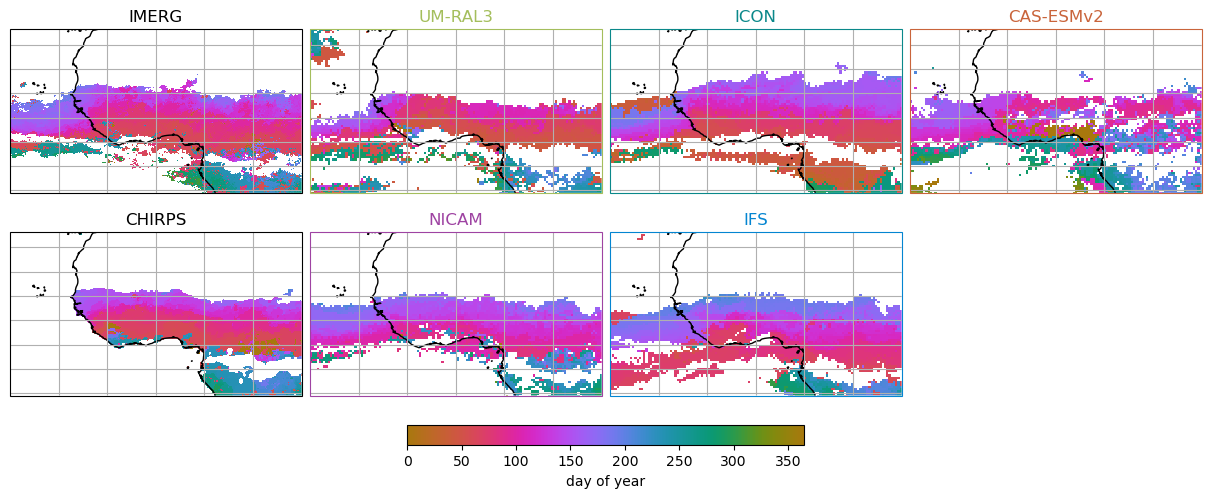

In [6]:
def plot_first_day(
    ax, sim, extent=None, zoom=7, period_ix=0, thresholds="", color="k", title=None
):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    if title == None:
        title = sim
    if sim.lower() == "chirps":
        da = (
            xr.open_dataset(f"onset_dates/{thresholds}/chirps_2020_dwtps.nc")
            .sel(period=period_ix)
            .first_day_of_period
        )
        mask = xr.open_dataarray(f"../global_monsoon/masks/chirps_2020.zarr")

    else:
        da = (
            xr.open_dataset(f"onset_dates/{thresholds}/{sim}_zoom_{zoom}_dwtps.nc")
            .sel(period=period_ix)
            .first_day_of_period
        )
        mask = hp_to_latlon(
            xr.open_dataarray(f"../global_monsoon/masks/{sim}_zoom_{zoom}.zarr"),
            zoom=zoom,
        )
    masked_da = da.where(mask)

    m = masked_da.plot(cmap=cmo.cm.phase, vmin=0, vmax=365, ax=ax, add_colorbar=False)

    ax.coastlines()
    ax.gridlines()
    ax.set_title(title, color=color)
    ax.tick_params(color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
    return ax, m

region="WAf"
figsize = (9, 6)
figsize = (12, 5)


left = domains[region]["lonmin"]
right = domains[region]["lonmax"]
bottom = domains[region]["latmin"]
top = domains[region]["latmax"]


projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    4,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_first_day(
    axes[0, 0], "IR_IMERG", [left, right, bottom, top], zoom=9, title="IMERG"
)

ax, m = plot_first_day(
    axes[1, 0],
    "CHIRPS",
    [left, right, bottom, top],
)

for sim_ix, sim in enumerate(sims):
    ax, m = plot_first_day(
        axes[int(np.floor(sim_ix / 3)), (sim_ix % 3) + 1],
        sim,
        [left, right, bottom, top],
        color=sim_colors[sim],
        title=sim_labels[sim],
    )



fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="day of year",
)
axes[1, 3].set_frame_on(False)

IR_IMERG
last day mean 224.11620180117163
first day mean 141.6898225059019


um_glm_n2560_RAL3p3_tuned_hk26
last day mean 186.02750582750582
first day mean 108.79324009324009


icon_d3hp003
last day mean 174.30160320641284
first day mean 111.49123246492987


casesm2_10km_nocumulus
last day mean 252.1268268516225
first day mean 171.72504334902155


nicam_gl11
last day mean 245.23330755349318
first day mean 174.61510698633668


ifs_tco3999-ng5_rcbmf_cf
last day mean 220.12284382284383
first day mean 154.93426573426572


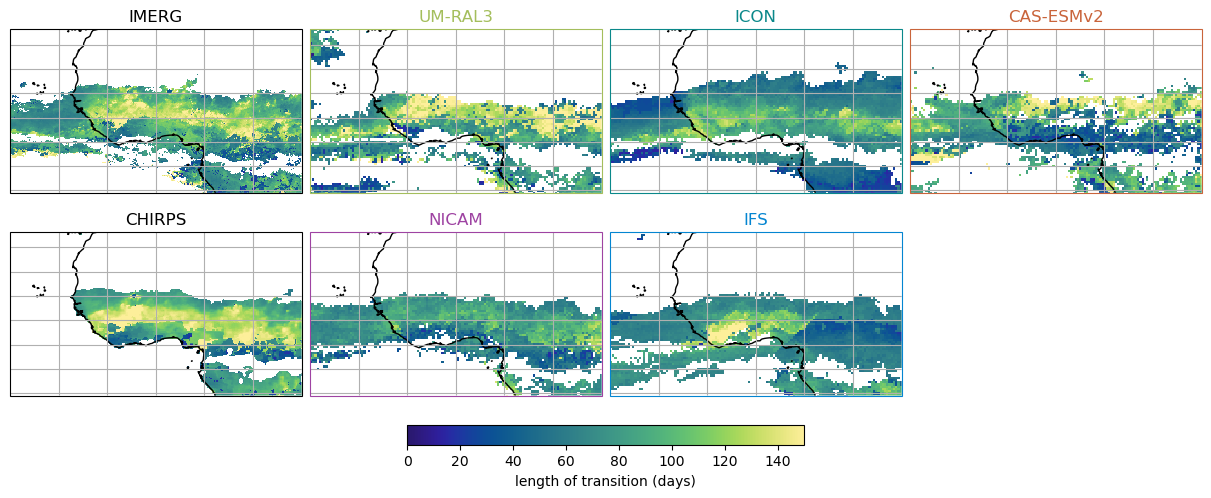

In [7]:
def plot_length(
    ax,
    sim,
    extent=None,
    zoom=7,
    period_ix=0,
    thresholds="",
    color="k",
    title=None,
):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    if title == None:
        title = sim
    if sim.lower() == "chirps":
        ds = (
            xr.open_dataset(f"onset_dates/{thresholds}/chirps_2020_dwtps.nc")
            .sel(period=period_ix)
            .rename({"lon": "longitude", "lat": "latitude"})
        )
        mask = xr.open_dataarray(f"../global_monsoon/masks/chirps_2020.zarr").rename(
            {"lon": "longitude", "lat": "latitude"}
        )
    else:
        ds = xr.open_dataset(
            f"onset_dates/{thresholds}/{sim}_zoom_{zoom}_dwtps.nc"
        ).sel(period=period_ix)
        mask = hp_to_latlon(
            xr.open_dataarray(f"../global_monsoon/masks/{sim}_zoom_{zoom}.zarr"),
            zoom=zoom,
        )
    da = ds.last_day_of_period - ds.first_day_of_period
    masked_da = da.where(mask)
    m = masked_da.plot(cmap=cmo.cm.haline, vmin=0, vmax=150, ax=ax, add_colorbar=False)
    if sim != "chirps":
        print(sim)
        print(
            "last day mean",
            ds.last_day_of_period.sel(
                longitude=slice(extent[0], extent[1]),
                latitude=slice(extent[2], extent[3]),
            )
            .mean(skipna=True)
            .values,
        )
        print(
            "first day mean",
            ds.first_day_of_period.sel(
                longitude=slice(extent[0], extent[1]),
                latitude=slice(extent[2], extent[3]),
            )
            .mean(skipna=True)
            .values,
        )

    ax.coastlines()
    ax.gridlines()
    ax.set_title(title, color=color)
    ax.tick_params(color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
    return ax, m


projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    4,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_length(
    axes[0, 0], "IR_IMERG", [left, right, bottom, top], zoom=9, title="IMERG"
)

ax, m = plot_length(
    axes[1, 0],
    "chirps",
    [left, right, bottom, top],
    title="CHIRPS"
)

for sim_ix, sim in enumerate(sims):
    ax, m = plot_length(
        axes[int(np.floor(sim_ix / 3)), (sim_ix % 3) + 1],
        sim,
        [left, right, bottom, top],
        color=sim_colors[sim],
        title=sim_labels[sim],
    )


fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="length of transition (days)",
)
axes[1, 3].set_frame_on(False)

### Just UM models

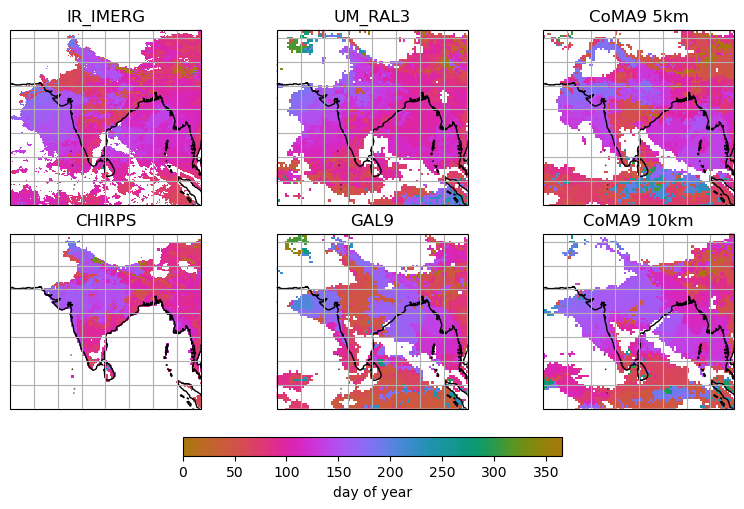

In [3]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    3,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)
ax, m = plot_first_day(
    axes[0, 0],
    "IR_IMERG",
    [left, right, bottom, top],
    zoom=9,
)
ax, m = plot_first_day(
    axes[1, 0],
    "CHIRPS",
    [left, right, bottom, top],
)
ax, m = plot_first_day(
    axes[0, 1],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    [left, right, bottom, top],
)
ax, m = plot_first_day(
    axes[1, 1],
    "um_glm_n1280_GAL9_v2_hk26",
    [left, right, bottom, top],
)
ax, m = plot_first_day(
    axes[0, 2],
    "um_glm_n2560_CoMA9_hk26",
    [left, right, bottom, top],
)
ax, m = plot_first_day(
    axes[1, 2],
    "um_glm_n1280_CoMA9_hk26",
    [left, right, bottom, top],
)

fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="day of year",
)
# axes[1,3].set_frame_on(False)

NameError: name 'plot_length' is not defined

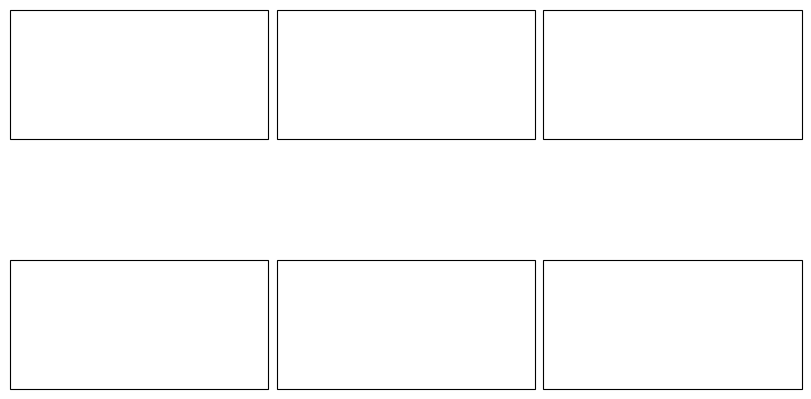

In [4]:

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    3,
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

ax, m = plot_length(
    axes[0, 0],
    "IR_IMERG",
    [left, right, bottom, top],
    zoom=9,
)
ax, m = plot_length(
    axes[1, 0],
    "CHIRPS",
    [left, right, bottom, top],
)
ax, m = plot_length(
    axes[0, 1],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    [left, right, bottom, top],
)
ax, m = plot_length(
    axes[1, 1],
    "um_glm_n1280_GAL9_v2_hk26",
    [left, right, bottom, top],
)
ax, m = plot_length(
    axes[0, 2],
    "um_glm_n2560_CoMA9_hk26",
    [left, right, bottom, top],
)
ax, m = plot_length(
    axes[1, 2],
    "um_glm_n1280_CoMA9_hk26",
    [left, right, bottom, top],
)

fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="length of transition (days)",
)

Text(0.5, 0.98, ' | zoom 5')

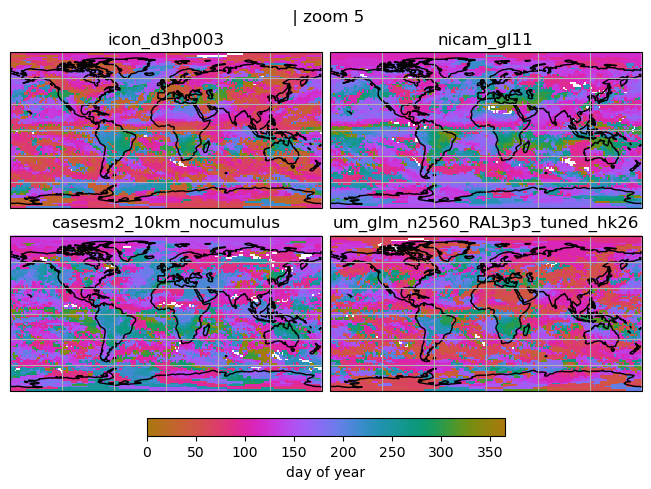

In [8]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)
zoom=5
thresholds=""
ax, m = plot_first_day(
    axes[0,0],
    "icon_d3hp003",
    # [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[1,0],
    "casesm2_10km_nocumulus",
    # [left, right, bottom, top],
    thresholds=thresholds,
)
ax, m = plot_first_day(
    axes[0,1],
    "nicam_gl11",
    # [left, right, bottom, top],
    thresholds=thresholds,
)

ax, m = plot_first_day(
    axes[1,1],
    "um_glm_n2560_RAL3p3_tuned_hk26",
    # [left, right, bottom, top],
    thresholds=thresholds,
)
fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="day of year",
)
plt.suptitle(f"{thresholds} | zoom {zoom}")